Alright, hey hey hey, it's me, Alex, though for some reason my user is labeled as alexa (I think it's because it uses my full first name and shortens it to five characters). Anyways, today I suppose this is the mini project, the first "big one." I feel a bit more relaxed in writing in this because I'm not in a word doc, so it feels slightly less informal, even though I understand this is mere illusion. 

So, what am I looking at? I have with me two datasets of residential property sales from 2010 and 2020, with another two datasets for both years cleaned to ensure the housing sales were >$1000. I also exported my very laboriously prepared neighborhood map of Grand Rapids, which I had to edit profusely in ArcPro due to a lot of neighborhoods that no longer exist being hidden beneath as polygon layers.

What I would like to do is see what neighborhoods have the most housing sales and least. I also want to look at the basic statistics for sales and compare sales from 2010 and 2020 to see how trends have changed. This focus is spawned from my thesis research on gentrification, and the goal here is to test-run some basic analysis to see if I can more easily do some of the work here than in a GIS. With gentrification, there is immense importance given to the property market, as buying property is the main way in which gentrifiers can move into a community, though housing sales alone are not enough to conclude if gentrification is taking place. 


In [204]:
#Importing random things I might need
import pandas as pd
import geopandas as gpd
import matplotlib
import matplotlib.pyplot as plt
import numpy as np
import json
import requests
import geodatasets as gd
import shapely.geometry

In [205]:
#Importing Grand Rapids Neighborhoods
grn = "C:/Users/alexa/Documents/Project Management and Programming/Neighborhoods/Neighborhoods.shp"
gdf = gpd.read_file(grn)
#Importing geocoded addresses for 2010 and 2020. The "combined" comes from the fact I had to geocode them in batches of csv files
a2010 = "C:/Users/alexa/Documents/Project Management and Programming/2010 Combined.csv"
a2020 = "C:/Users/alexa/Documents/Project Management and Programming/2020 Combined.csv"

dfa2010 = pd.read_csv(a2010)
dfa2020 = pd.read_csv(a2020)

<Axes: >

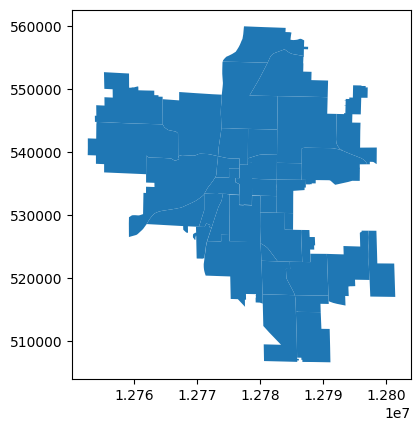

In [206]:
#Testing Neighborhood Map
gdf.plot()

In [207]:
gdf.crs

<Projected CRS: PROJCS["NAD_1983_StatePlane_Michigan_South_FIPS_21 ...>
Name: NAD_1983_StatePlane_Michigan_South_FIPS_2113_IntlFeet
Axis Info [cartesian]:
- [east]: Easting (foot)
- [north]: Northing (foot)
Area of Use:
- undefined
Coordinate Operation:
- name: unnamed
- method: Lambert Conic Conformal (2SP)
Datum: North American Datum 1983
- Ellipsoid: GRS 1980
- Prime Meridian: Greenwich

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

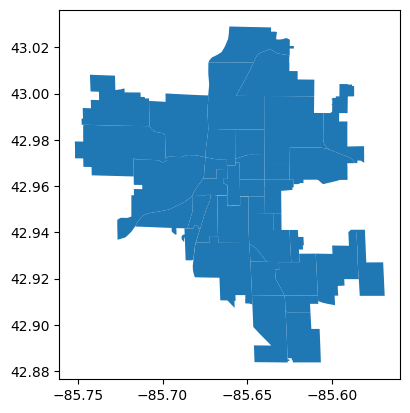

In [208]:
#Changing gdf to wgs 1984 becauses geocoding was seemingly done with Google Maps
wgsgdf = gdf.to_crs(4326)
wgsgdf.plot()
wgsgdf.crs

In [209]:
#Turning the addresses into geodataframes to be plotted.
gdf2010 = gpd.GeoDataFrame(
    dfa2010, geometry=gpd.points_from_xy(dfa2010.x, dfa2010.y), crs="EPSG:4326"
)
gdf2020 = gpd.GeoDataFrame(
    dfa2020, geometry=gpd.points_from_xy(dfa2020.x, dfa2020.y), crs="EPSG:4326"
)
print(gdf2020.head)

<bound method NDFrame.head of       Old ID   Sale Date    Sale Price               Address  \
0          1  12/31/2020        $0.00      2051 SW MCKEE AVE   
1          2  12/31/2020        $0.00        410 NW TENTH ST   
2          3  12/31/2020        $1.00     101 SW DELONEY AVE   
3          4  12/31/2020   $50,000.00     506 NW SWIONTEK PL   
4          5  12/31/2020        $1.00   1519 NW GARFIELD AVE   
...      ...         ...           ...                   ...   
7449    7450    1/2/2020  $172,000.00    1014 NE FOUNTAIN ST   
7450    7451    1/2/2020  $119,000.00      222 NW VALLEY AVE   
7451    7452    1/1/2020        $0.00   1108 SW SHERIDAN AVE   
7452    7453    1/1/2020        $0.00      1860 SE BOSTON ST   
7453    7454    1/1/2020  $137,930.00      2448 NE PARIS AVE   

                          Grantor                         Grantee  \
0                  HERREMA DANIEL     GARCIA ESTEBAN TOLEDO ET AL   
1     SWING BRIDGE PROPERTIES LLC  CONRAD SCOTT FKA CLOWARD SCO

<Axes: >

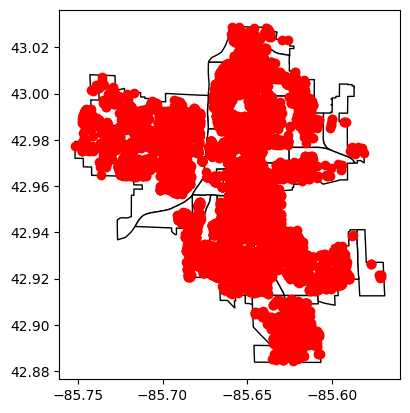

In [210]:
#2010 Address map
ax2010 = wgsgdf.plot(color="white",edgecolor="black")
gdf2010.plot(ax=ax2010, color="red")

<Axes: >

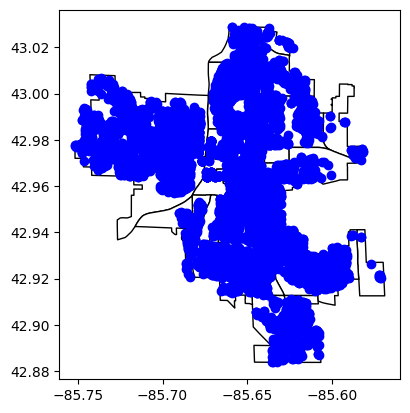

In [211]:
#2020 Address map
ax2020 = wgsgdf.plot(color="white",edgecolor="black")
gdf2020.plot(ax=ax2020, color="blue")

These maps look very similar. Also I cannot express how horrifically long it took to find and deal with outliers, but at last it's all finally valid. Most of the effort for this mini project was in finding and cleaning the data.

<Axes: >

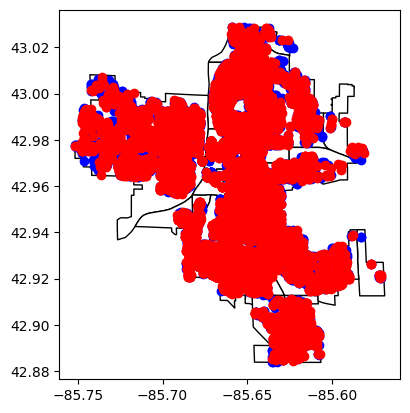

In [212]:
#Can I combine them?
axcom = wgsgdf.plot(color="white",edgecolor="black")
gdf2020.plot(ax=axcom, color="blue")
gdf2010.plot(ax=axcom, color="red")

Seems it worked. As much as I want to go to bed and bathe in the shame of letting this be turned in another day late, I will perservere and deal with the analysis. First, however, I will whittle down the number of records to only include property sales, meaning those sold at >$1000. Anything with a lower price I will assume was just a transference of ownership without a real sale.

In [213]:
as2010 = "C:/Users/alexa/Documents/Project Management and Programming/2010 Actual Sales.csv"
as2020 = "C:/Users/alexa/Documents/Project Management and Programming/2020 Actual Sales.csv"
dfas2010 = pd.read_csv(as2010)
dfas2020 = pd.read_csv(as2020)

In [214]:
gdfas2010 = gpd.GeoDataFrame(
    dfas2010, geometry=gpd.points_from_xy(dfas2010.x, dfas2010.y), crs="EPSG:4326"
)
gdfas2020 = gpd.GeoDataFrame(
    dfas2020, geometry=gpd.points_from_xy(dfas2020.x, dfas2020.y), crs="EPSG:4326"
)
print(gdfas2010.head)

<bound method NDFrame.head of         ID  Old ID   Sale Date  Sale Price              Address  \
0        1       2  12/31/2010     21000.0     3011 NE EFFIE PL   
1        2       6  12/31/2010     40000.0  103 NE BENJAMIN AVE   
2        3      10  12/31/2010    106000.0  1241 NE ELLSMERE ST   
3        4      11  12/31/2010     85202.0   202 NW WESTMONT DR   
4        5      12  12/31/2010     84900.0    2054 SE PARIS AVE   
...    ...     ...         ...         ...                  ...   
5223  5224    9422    1/1/2010     41669.0      2179 SE 32ND ST   
5224  5225    9423    1/1/2010     26000.0    135 NE BARNETT ST   
5225  5226    9425    1/1/2010     74318.0   1810 SW TOWNER AVE   
5226  5227    9426    1/1/2010    116651.0  917 SE EVERGLADE DR   
5227  5228    9427    1/1/2010     81395.0    818 SE NELAND AVE   

                   Grantor                          Grantee     Parcel Number  \
0          PHILLIPS CHERYL              SIMS ERICA DANIELLE  41-14-06-403-027   
1  

<Axes: >

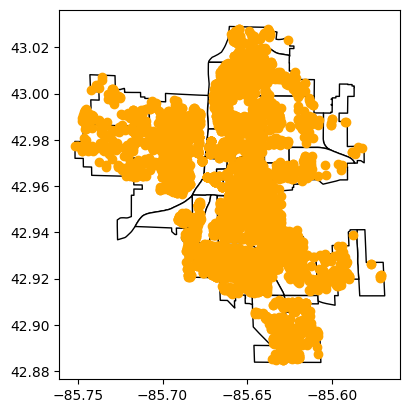

In [215]:
#2010 Actual sales
axas2010 = wgsgdf.plot(color="white",edgecolor="black")
gdfas2010.plot(ax=axas2010, color="orange")

<Axes: >

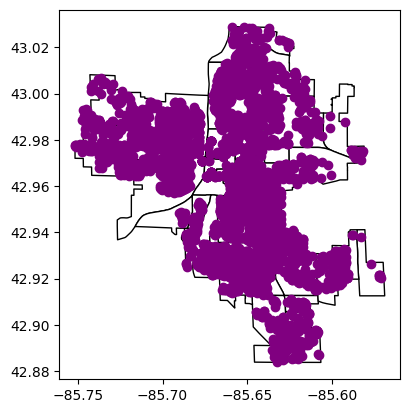

In [216]:
#2020 Actual sales
axas2020 = wgsgdf.plot(color="white",edgecolor="black")
gdfas2020.plot(ax=axas2020, color="purple")

<Axes: >

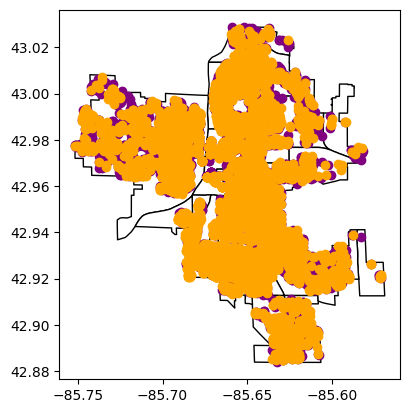

In [217]:
#But how do they look together?
axascom = wgsgdf.plot(color="white",edgecolor="black")
gdfas2020.plot(ax=axascom, color="purple")
gdfas2010.plot(ax=axascom, color="orange")

In [218]:
#Double checking to ensure everything is in WGS 84. This is because spatial joins require congruent crs's
gdfas2020.crs


<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [219]:
wgsgdf.head()

,NEBRH,Email,Phone,Creator,Create_Dat,Editor,Last_Edito,CreationDa,Creator_1,EditDate,Editor_1,GlobalID,Shape_Leng,Shape_Area,geometry
0,North Park,None,None,None,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{0EEEC19E-696D-49C8-916B-8055CA517E22},36406.883652,4.632312e+07,"POLYGON ((-85.63163 43.02341, -85.63117 43.023..."
1,North End,None,None,None,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{1608CED1-774A-4391-8B49-1E0058EAC52E},35717.242952,5.740824e+07,"POLYGON ((-85.62482 43.01654, -85.62481 43.016..."
2,Creston,contact@crestongr.com,None,None,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{7802D509-3D1B-4BE9-96ED-9ACA5A5545A0},42184.814033,7.739928e+07,"POLYGON ((-85.66278 43.01353, -85.65924 43.013..."
3,Richmond-Oakleigh,None,None,None,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{7A460FE1-0967-4EFA-AA41-8D0ED6C636EA},40369.538758,6.050100e+07,"POLYGON ((-85.70795 42.99685, -85.70789 42.994..."
4,Leffingwell-Twin Lakes,None,None,None,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{FD506C35-58CE-4A98-9231-A7C4A5206999},41602.788597,3.790914e+07,"POLYGON ((-85.58671 43.0024, -85.58674 42.9988..."


In [220]:
#Aright, now it's time to join the sold addresses for each year with the neighborhoods.
asn2010 = gpd.sjoin(gdfas2010, wgsgdf, how="inner", predicate="within")
asn2020 = gpd.sjoin(gdfas2020, wgsgdf, how="inner", predicate="within")
asn2010.head()

,ID,Old ID,Sale Date,Sale Price,Address,Grantor,Grantee,Parcel Number,City,State/Province,...,Create_Dat,Editor,Last_Edito,CreationDa,Creator_1,EditDate,Editor_1,GlobalID,Shape_Leng,Shape_Area
0,1,2,12/31/2010,21000.0,3011 NE EFFIE PL,PHILLIPS CHERYL,SIMS ERICA DANIELLE,41-14-06-403-027,Grand Rapids,Michigan,...,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{0EEEC19E-696D-49C8-916B-8055CA517E22},36406.883652,4.632312e+07
1,2,6,12/31/2010,40000.0,103 NE BENJAMIN AVE,SIMONAIT JOHN SUSAN,SIMONAIT JOHN C,41-14-29-252-020,Grand Rapids,Michigan,...,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{F292942B-921A-446B-8BB3-C79FE9EC901B},13122.634054,1.040174e+07
2,3,10,12/31/2010,106000.0,1241 NE ELLSMERE ST,MEANEY VINCE KAREN E,TUTSCH ANDREA JASON,41-14-08-202-008,Grand Rapids,Michigan,...,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{1608CED1-774A-4391-8B49-1E0058EAC52E},35717.242952,5.740824e+07
3,4,11,12/31/2010,85202.0,202 NW WESTMONT DR,GELUSO SAM TRUST,SUTHERLAND JENNIFER L,41-13-27-252-009,Grand Rapids,Michigan,...,NaT,None,NaT,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,2026-02-13,mdeemer@grand_rapids.mi.us_grandrapids,{99925E81-793D-4483-86B7-0C200A512A45},50988.834211,9.234827e+07
4,5,12,12/31/2010,84900.0,2054 SE PARIS AVE,UNION CAPITAL,MILLER MELISSA A NATHAN M,41-18-07-204-015,Grand Rapids,Michigan,...,NaT,None,NaT,NaT,None,NaT,None,{D5119BF0-96FB-4692-88A5-57FB190EC01E},42394.682870,6.862194e+07


The spatial join worked, as some of the fields from wgsgdf appear in the head() values for the asn geodataframes, but at the same time, it seems the NEBRH field, the field that actually has the neighborhood title, isn't included. WHYYYYYYYYYYYYYYY?!?!?!?!?!!?!?!?!?!?!?!?!?!?!?!

If I print the values for the crs-transformed neighborhood gdf, wgsgdf, I can get a list of neighborhoods and their index values, which will at least be useful. Plus, on account of how few there are, I can just cross-reference the index position and the neighborhood name, so I guess that vaguely works.

In [221]:
print(wgsgdf['NEBRH'])

0                 North Park
1                  North End
2                    Creston
3          Richmond-Oakleigh
4     Leffingwell-Twin Lakes
5                 West Grand
6                  Northeast
7              Shawmut Hills
8            Belknap Lookout
9              Highland Park
10             Michigan Oaks
11            John Ball Park
12                   Midtown
13                  Downtown
14             Heritage Hill
15            Fulton Heights
16         Oldtown-Heartside
17                East Hills
18                   Eastown
19                Grandville
20               Black Hills
21                    Baxter
22             Southeast End
23              Ottawa Hills
24                  Eastgate
25            Lake Eastbrook
26            Eastern-Burton
27              Shawnee Park
28             Alger Heights
29            ken-O-Sha Park
30               Shangrai-La
31                 Southwest
32       Southeast Community
33            Roosevelt Park
34            

In [222]:
#Alright, I learned I can use the groupby func to somehow get a count of neighborhoods by polygon.
asnc2010 = asn2010.groupby('index_right').size()
asnc2020 = asn2020.groupby('index_right').size()
wgsgdf['count2010'] = asnc2010
wgsgdf['count2020'] = asnc2020

In [223]:
#Number of sales per neighborhood in 2010
print(wgsgdf['count2010'])
print("Total number of sales in 2010:", wgsgdf['count2010'].sum())

0      97
1     173
2     450
3     108
4      13
5     553
6     128
7     157
8     107
9     109
10     42
11    392
12    108
13     15
14    152
15     49
16     29
17    115
18    124
19     55
20     38
21     62
22    472
23     17
24     36
25      8
26     59
27     73
28    191
29    114
30     37
31     18
32    249
33    120
34     82
35    567
36     85
Name: count2010, dtype: int64
Total number of sales in 2010: 5204


Alright, there are 5204 sales in total. The neighborhoods with the most real sales include Garfield Park with 567, West Grand with 553, Southeast End with 472, Creston with 450, and John Ball Park with 392. Interesting that this should be the case, as in my preliminary research on this topic, all of these neighborhoods were hypothesized to be undergoing gentrification, and they happen to see far more property sales than any other, a possible indicator. Creston is in the north of Grand Rapids, John Ball Park and West Grand are to the west of the Grand River, and the other two are in the southern part of the city. For the least sales, there is Lake Eastbrook with 8, Leffingwell Twin-lakes with 13, and Downtown with 15. The latter two are in more wealthier parts of town, but Lake Eastbrook is to the south, in what can be regarded as a more impoverished area. But how did that change going into 2020?

In [224]:
#Number of sales per neighborhood in 2010


print(wgsgdf['count2020'])
print("Total number of sales in 2020:", wgsgdf['count2020'].sum())

0     107
1     195
2     386
3     117
4      15
5     409
6     131
7     250
8      85
9      83
10     36
11    261
12    107
13     36
14    118
15     64
16     10
17     90
18     92
19     39
20     12
21     84
22    300
23     16
24     45
25      9
26     41
27     74
28    151
29     76
30     28
31      9
32    201
33     44
34     88
35    343
36     96
Name: count2020, dtype: int64
Total number of sales in 2020: 4248


For 2020 we see a reduction in total sales down to 4248. The neighborhoods with the most real sales include West Grand with 409, Creston with 386, Garfield Park with 343, Southeast End with 300, and John Ball Park with 261. The same places, but with significantly reduced numbers. There are nearly a thousand less sales a decade later, though the pandemic may have played some role in this, which is why going forward I need to complete the dataset to include data between 2010 and 2020, as well as data that came afterwards. 

It is time to compare the two datasets with some matplotlib analysis.

### 2010 Data


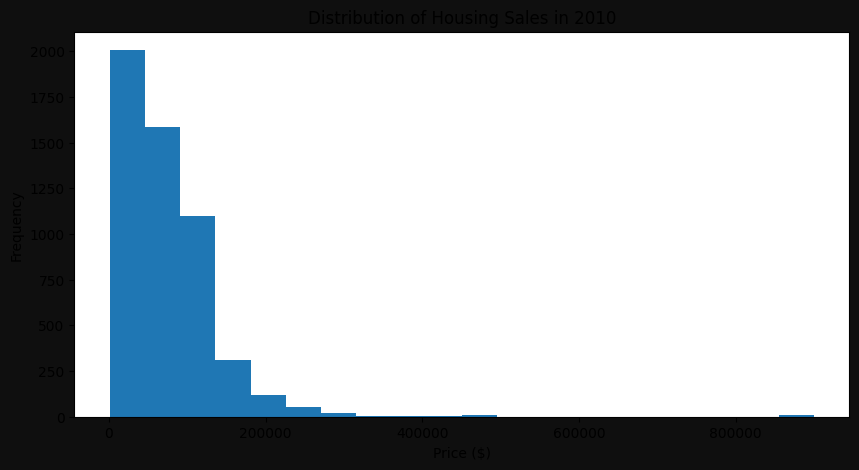

In [225]:
#dfas2010 = pd.read_csv(as2010)
#dfas2020 = pd.read_csv(as2020)
fig, ax = plt.subplots(figsize=(8,10),facecolor='#0f0f0f')
dfas2010['Sale Price'].hist(bins=20, figsize=(10, 5))
plt.title('Distribution of Housing Sales in 2010')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
ax.grid(False)

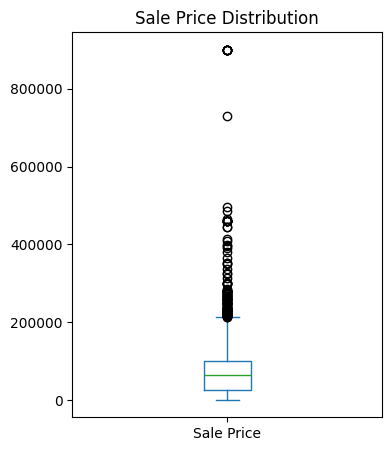

In [226]:
dfas2010['Sale Price'].plot(kind='box', figsize=(4, 5))
plt.title('Sale Price Distribution')
plt.show()

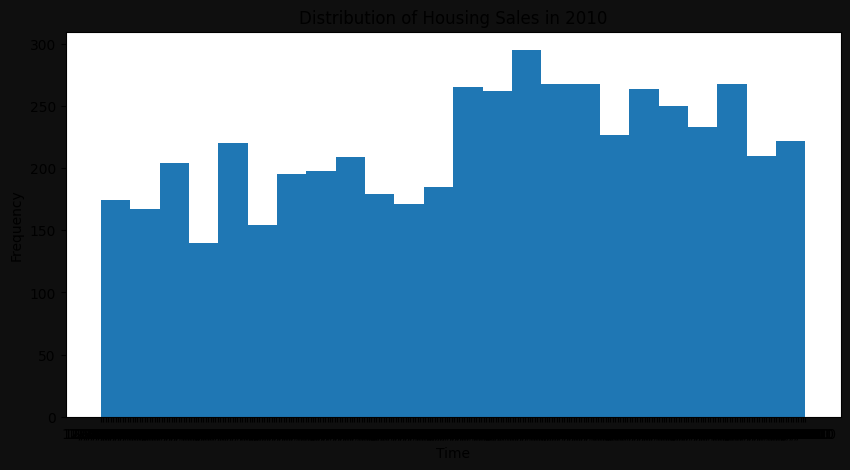

In [227]:
fig, ax = plt.subplots(figsize=(8,10),facecolor='#0f0f0f')
dfas2010['Sale Date'].hist(bins=24, figsize=(10, 5))
plt.title('Distribution of Housing Sales in 2010')
plt.xlabel('Time')
plt.ylabel('Frequency')
ax.grid(False)

### 2020 Data

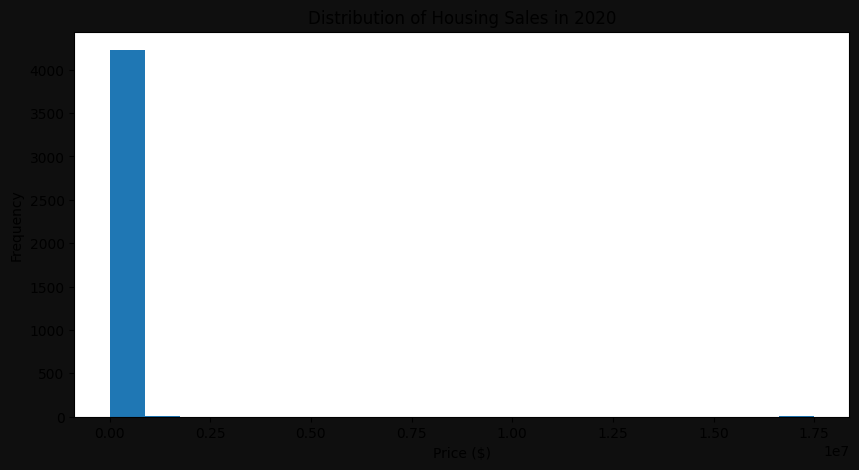

In [231]:
fig, ax = plt.subplots(figsize=(8,10),facecolor='#0f0f0f')
dfas2020['Sale Price'].hist(bins=20, figsize=(10, 5))
plt.title('Distribution of Housing Sales in 2020')
plt.xlabel('Price ($)')
plt.ylabel('Frequency')
ax.grid(False)

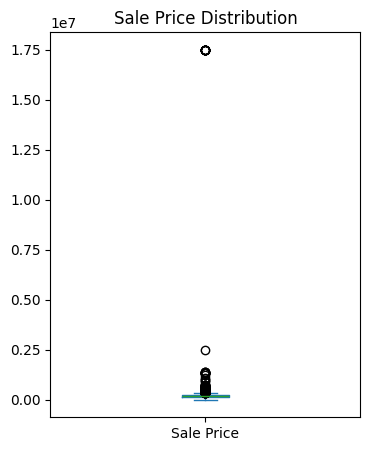

In [ ]:
dfas2020['Sale Price'].plot(kind='box', figsize=(4, 5))
plt.title('Sale Price Distribution')
plt.show()
#It initially showed a chart similar to 2020 for frequency, then I tried making a boxplot and decalred there was no numerical value.
#I then changed the format to number, and it for some reason thought it was a decimal. I have been stuck on this for too long noow
#I cannot comprehend the issue, or why it thinks normal number format records are decimals.

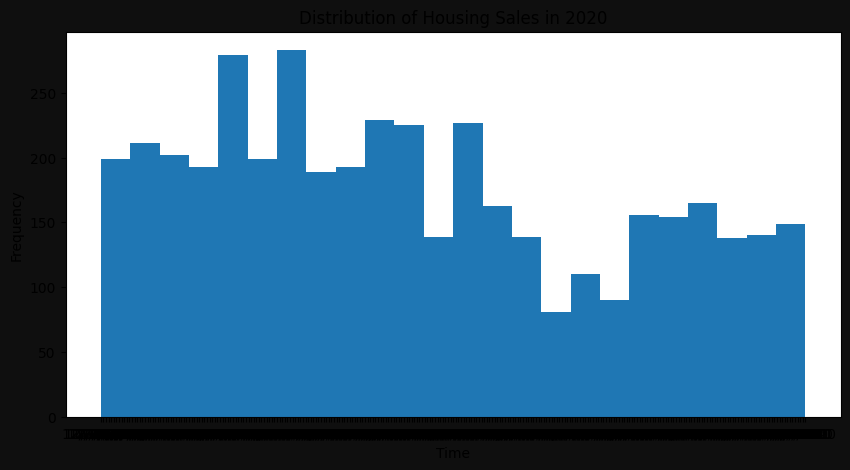

In [230]:
fig, ax = plt.subplots(figsize=(8,10),facecolor='#0f0f0f')
dfas2020['Sale Date'].hist(bins=24, figsize=(10, 5))
plt.title('Distribution of Housing Sales in 2020')
plt.xlabel('Time')
plt.ylabel('Frequency')
ax.grid(False)


Although the frequency charts randomly decided to disagree with me the instant I changed the number formatting in Excel to numeric, it should be noted that they were relatively similar, though 2020 had some perhaps a slightly higher frequency for more expensive houses.
In terms of time of purchase, it's interesting to see that in 2010 there were more homes purchased in the second half of the year, while in 2020 this is reversed, perhaps because of the pandemic. I tried but cannot seem to find a way to aggregate prices by neighborhood, and I believe this would require work with normal GIS software. Regardless, I will say that I've learned quite a bit from this project, particularly in terms of where most of the housing is being sold (or not being sold). It's also interesting to note the fairly intense drop in property sales, especially when considering how the population has actually grown over the past 15 years overall. 

I've been working on this essentially all night, so I hope this is enough work. Getting everything, even if it's this limited, to function properly has been a challenge, so I hope this is at least enough for a mini project.
I'll get to exporting things to Arc now. I will port the actual housing sales.

In [237]:
gdfas2010.to_file('Grand Rapids 2010 Residential Property Sales.GeoJSON', driver="GeoJSON")
gdfas2020.to_file('Grand Rapids 2020 Residential Property Sales.GeoJSON', driver="GeoJSON")



In [232]:
from arcgis.gis import GIS
def agol_login():
    import getpass
    print("Portal for ArcGIS as a built in user")
    pwd = getpass.getpass('PASSWORD: ')
    username = getpass.getpass('USERNAME: ')
    gis = GIS("https://wmugeography.maps.arcgis.com",username, pwd)
    print("Logged in as: " + gis.properties.user.username)
    return gis

In [234]:
gis = agol_login()

Portal for ArcGIS as a built in user
Logged in as: ABucherWMU26


In [238]:
# create an item_properties dict
item_properties = {
    "title": "Grand Rapids 2010 Residential Property Sales",
    "description": "Grand Rapids 2010 Residential Property Sales",
    "tags": "GEOG6670-4670",
    "type": "GeoJson"
}

geojson_file_path = 'Grand Rapids 2010 Residential Property Sales.geojson'
geojson_item = gis.content.add(item_properties, geojson_file_path)

new_service = geojson_item.publish()
new_service

C:\Users\alexa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\interactiveshell.py:3701: DeprecatedWarning: add is deprecated as of 2.3.0 and has been removed in 3.0.0. Use `Folder.add()` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)
C:\Users\alexa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arcgis\graph\data_model_types.py:68: PydanticDeprecatedSince20: Support for class-based `config` is deprecated, use ConfigDict instead. Deprecated in Pydantic V2.0 to be removed in V3.0. See Pydantic V2 Migration Guide at https://errors.pydantic.dev/2.12/migration/
  class GraphProperty(BaseModel):
C:\Users\alexa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\arcgis\graph\data_model_types.py:271: PydanticDeprecatedSince20: Support for class-b

<Item title:"Grand Rapids 2010 Residential Property Sales" type:Feature Layer Collection owner:ABucherWMU26>

Woah it worked. Link: https://wmugeography.maps.arcgis.com/home/item.html?id=d80904d910974811acad33b456bb7833 

In [ ]:
# create an item_properties dict
item_properties = {
    "title": "Grand Rapids 2020 Residential Property Sales",
    "description": "Grand Rapids 2020 Residential Property Sales",
    "tags": "GEOG6670-4670",
    "type": "GeoJson"
}

geojson_file_path = 'Grand Rapids 2020 Residential Property Sales.geojson'
geojson_item = gis.content.add(item_properties, geojson_file_path)

new_service = geojson_item.publish()
new_service

#Ignore the error, it did work

C:\Users\alexa\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\LocalCache\local-packages\Python313\site-packages\IPython\core\interactiveshell.py:3701: DeprecatedWarning: add is deprecated as of 2.3.0 and has been removed in 3.0.0. Use `Folder.add()` instead.
  exec(code_obj, self.user_global_ns, self.user_ns)


KeyboardInterrupt: 

For some reason it isn't showing as done, but the second published item does show up on my ArcGIS Online account, so it did work. https://wmugeography.maps.arcgis.com/home/item.html?id=8b550869335b4cb096cbeea8526e6cbf
